In [80]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [81]:
N = 100

X = 1 + 10 * (np.random.ranf(N) - 0.5)
Y = 1 + 10 * (np.random.ranf(N) - 0.5)

X = np.append(X, 10 + 10 * (np.random.ranf(N) - 0.5))
Y = np.append(Y, 10 + 10 * (np.random.ranf(N) - 0.5))

D = np.column_stack((X, Y))

labels = np.append(np.zeros(int(N)), np.ones(int(N))).astype(int)

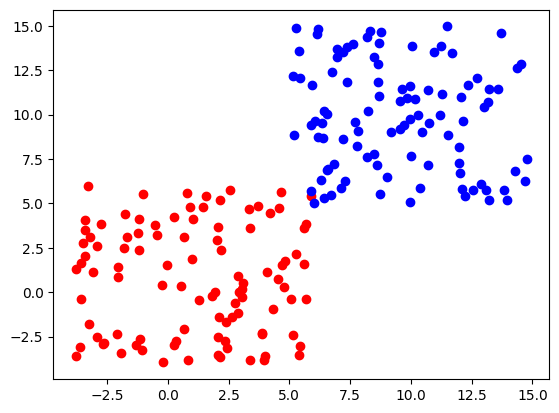

In [82]:
plt.scatter(X[labels == 0], Y[labels == 0], c='red')
plt.scatter(X[labels == 1], Y[labels == 1], c='blue')
plt.show()

In [83]:
def KNN(k, p, D, labels):
  Dists = np.linalg.norm(D - p, axis=1)
  idx = np.argsort(Dists)[:k]
  return np.bincount(labels[idx].ravel()).argmax()

In [84]:
K = int(N**0.5)

x, y = [int(i) for i in input("Enter A Point: ").strip().split()]
label = KNN(K, np.array([x, y]), D, labels)

print(label == 0 and "Red" or "Blue")

Red


In [85]:
def select_k(D, labels, k_values, folds=5):
    idx = np.arange(len(D))
    np.random.shuffle(idx)

    D, labels = D[idx], labels[idx]
    fold_size = len(D) // folds

    best_k = None
    best_acc = 0

    for k in k_values:
        accs = []

        for i in range(folds):
            start = i * fold_size
            end = start + fold_size

            X_val = D[start:end]
            y_val = labels[start:end]

            X_train = np.concatenate((D[:start], D[end:]))
            y_train = np.concatenate((labels[:start], labels[end:]))

            correct = 0
            for p, y_true in zip(X_val, y_val):
                y_pred = KNN(k, p, X_train, y_train)
                if y_pred == y_true:
                    correct += 1

            accs.append(correct / len(X_val))

        avg_acc = np.mean(accs)

        if avg_acc > best_acc:
            best_acc = avg_acc
            best_k = k

    return best_k, best_acc

k_values = range(1, K)
best_k, acc = select_k(D, labels, k_values)

print("Best K:", best_k, "Accuracy:", acc)

Best K: 3 Accuracy: 0.9949999999999999
